# Modèle 4 — MLP (Deep Learning)

Le MLP (Multilayer Perceptron) est un réseau de neurones multicouches implémenté en PyTorch.
Il est capable de capturer des interactions non linéaires complexes entre les features
que les modèles classiques pourraient rater.

**Justification de l'utilisation du Deep Learning ici :**
Le dataset contient 32 features initiales (et davantage après encodage OHE) avec des
interactions potentiellement non triviales entre comportements d'engagement, métriques
financières et indicateurs de satisfaction. Le MLP peut en théorie modéliser ces
interactions automatiquement.

**Limitation attendue :** Avec seulement 10 000 observations, le MLP risque de peiner
à surpasser XGBoost. On s'y attend et on le documentera dans la comparaison.

In [9]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold

from src.data.loader import PROCESSED_DIR
from src.evaluation.metrics import (
    compute_classification_metrics, print_classification_report,
    plot_roc_curve, plot_confusion_matrix
)
from src.models.mlflow_utils import setup_mlflow, log_pytorch_classification_run, EXPERIMENT_CHURN

plt.rcParams['figure.dpi'] = 110
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositif utilisé : {DEVICE}")

X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv').values.astype(np.float32)
X_test = pd.read_csv(PROCESSED_DIR / 'X_test.csv').values.astype(np.float32)
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze().values.astype(np.float32)
y_test = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze().values.astype(np.float32)
feature_names = joblib.load(PROCESSED_DIR / 'feature_names.joblib')

INPUT_DIM = X_train.shape[1]
print(f"Dimension d'entrée : {INPUT_DIM} features")

Dispositif utilisé : cuda
Dimension d'entrée : 58 features


## 1. Architecture du réseau

In [10]:
class ChurnMLP(nn.Module):
    """
    Réseau MLP à 3 couches cachées pour la classification de churn.

    Architecture choisie :
    - Couches décroissantes (256 → 128 → 64) : progressivement plus abstraite
    - BatchNorm après chaque couche : stabilise et accélère l'entraînement
    - Dropout (0.3) : régularisation contre l'overfitting, critique avec 10k obs
    - ReLU : non-linéarité standard, évite le vanishing gradient vs sigmoid
    - Pas de sigmoid en sortie : BCEWithLogitsLoss l'applique en interne de façon
      numériquement plus stable ; on applique torch.sigmoid() manuellement à l'inférence
    """

    def __init__(self, input_dim: int, dropout_rate: float = 0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


model = ChurnMLP(input_dim=INPUT_DIM, dropout_rate=0.3).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nNombre total de paramètres : {total_params:,}")

ChurnMLP(
  (network): Sequential(
    (0): Linear(in_features=58, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

Nombre total de paramètres : 57,217


## 2. Préparation des DataLoaders

In [11]:
X_train_t = torch.tensor(X_train).to(DEVICE)
y_train_t = torch.tensor(y_train).to(DEVICE)
X_test_t = torch.tensor(X_test).to(DEVICE)
y_test_t = torch.tensor(y_test).to(DEVICE)

BATCH_SIZE = 256
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Poids de classe pour compenser le déséquilibre 90/10.
# BCEWithLogitsLoss applique ce poids uniquement sur les exemples positifs (churners),
# ce qui revient à multiplier leur contribution à la loss par le ratio négatifs/positifs.
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos]).to(DEVICE)
print(f"pos_weight : {pos_weight.item():.2f}")

# BCEWithLogitsLoss combine sigmoid + BCE en une seule opération numériquement stable.
# C'est la seule variante PyTorch qui supporte pos_weight pour corriger le déséquilibre.
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# ReduceLROnPlateau réduit le learning rate quand la val_loss stagne
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

pos_weight : 8.79


## 3. Boucle d'entraînement

In [12]:
N_EPOCHS = 50
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_state = None

for epoch in range(N_EPOCHS):
    # Entraînement
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_hat = model(X_batch)
        loss = criterion(y_hat, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(X_batch)
    epoch_loss /= len(X_train_t)
    train_losses.append(epoch_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        val_proba = model(X_test_t)
        val_loss = criterion(val_proba, y_test_t).item()
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Sauvegarde du meilleur modèle (early stopping manuel)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f"Époque {epoch+1:3d}/{N_EPOCHS} | train_loss={epoch_loss:.4f} | val_loss={val_loss:.4f}")

# On recharge le meilleur état du modèle
model.load_state_dict(best_model_state)
print(f"\nMeilleure val_loss : {best_val_loss:.4f}")

Époque  10/50 | train_loss=0.9207 | val_loss=1.1081
Époque  20/50 | train_loss=0.7763 | val_loss=1.1747
Époque  30/50 | train_loss=0.7270 | val_loss=1.2227
Époque  40/50 | train_loss=0.7276 | val_loss=1.2224
Époque  50/50 | train_loss=0.7121 | val_loss=1.2342

Meilleure val_loss : 1.0588


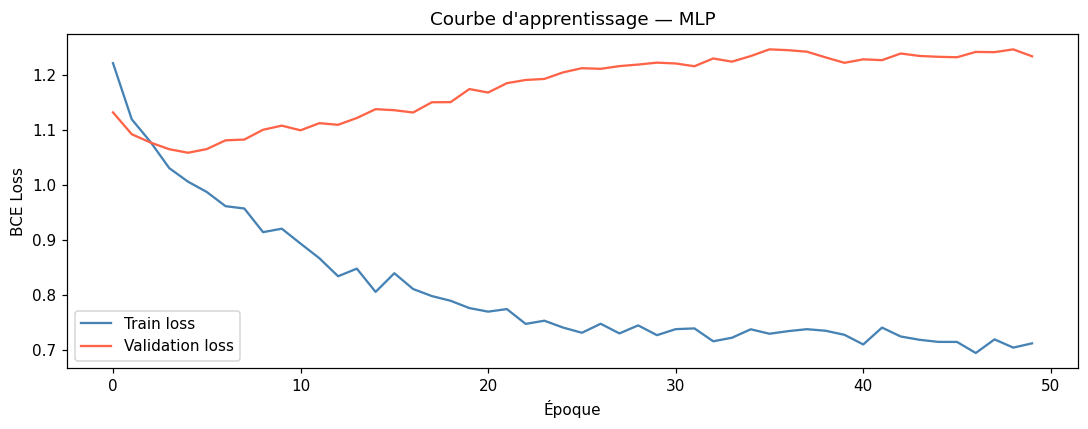

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train loss', color='steelblue')
ax.plot(val_losses, label='Validation loss', color='tomato')
ax.set_xlabel('Époque')
ax.set_ylabel('BCE Loss')
ax.set_title('Courbe d\'apprentissage — MLP')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig_mlp_learning_curve.png', bbox_inches='tight')
plt.show()

## 4. Évaluation

In [14]:
model.eval()
with torch.no_grad():
    # Le modèle sort des logits (pas de sigmoid final) — on applique sigmoid ici
    # pour obtenir des probabilités interprétables entre 0 et 1.
    y_proba = torch.sigmoid(model(X_test_t)).cpu().numpy()

y_pred = (y_proba >= 0.5).astype(int)
metrics = compute_classification_metrics(y_test.astype(int), y_pred, y_proba)
print_classification_report(y_test.astype(int), y_pred, 'MLP (Deep Learning)')

print("\nMétriques :")
for k, v in metrics.items():
    print(f"  {k} : {v:.4f}")


Rapport de classification — MLP (Deep Learning)
--------------------------------------------------
              precision    recall  f1-score   support

   Non-Churn       0.96      0.64      0.76      1796
       Churn       0.19      0.74      0.30       204

    accuracy                           0.65      2000
   macro avg       0.57      0.69      0.53      2000
weighted avg       0.88      0.65      0.72      2000


Métriques :
  accuracy : 0.6465
  auc_roc : 0.7540
  f1_weighted : 0.7163
  f1_churn : 0.2993
  precision_churn : 0.1876
  recall_churn : 0.7402
  log_loss : 0.5993


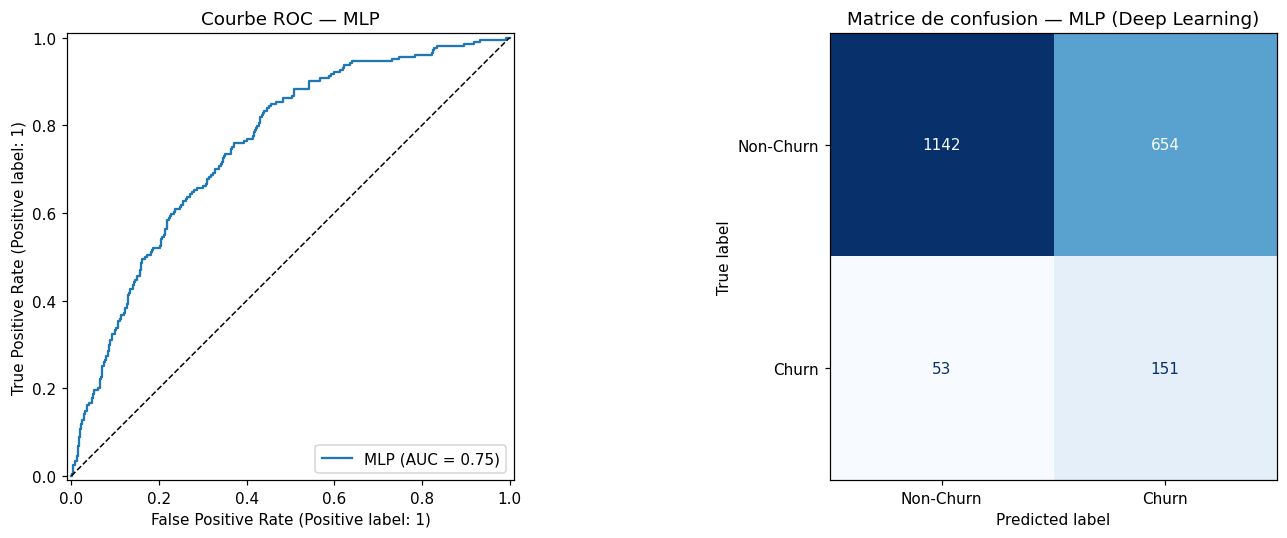

In [15]:
from sklearn.metrics import RocCurveDisplay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test.astype(int), y_proba, ax=axes[0], name='MLP')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_title('Courbe ROC — MLP')

from src.evaluation.metrics import plot_confusion_matrix
plot_confusion_matrix(y_test.astype(int), y_pred, 'MLP (Deep Learning)', ax=axes[1])

plt.tight_layout()
plt.savefig('../data/processed/fig_mlp_roc_cm.png', bbox_inches='tight')
plt.show()

## 5. Enregistrement MLflow

In [16]:
setup_mlflow(EXPERIMENT_CHURN)

params = {
    'architecture': '256-128-64-1',
    'dropout_rate': 0.3,
    'n_epochs': N_EPOCHS,
    'batch_size': BATCH_SIZE,
    'optimizer': 'AdamW',
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'activation': 'ReLU',
    'class_weighting': 'BCEWithLogitsLoss pos_weight',
    'device': str(DEVICE),
}

run_id = log_pytorch_classification_run(
    model=model,
    model_name='MLP (PyTorch)',
    params=params,
    metrics=metrics,
    X_train=X_train,
    X_test=X_test,
    input_dim=INPUT_DIM,
)

# Sauvegarde locale
torch.save(model.state_dict(), PROCESSED_DIR / 'model_mlp_state.pth')
print(f"Run MLflow : {run_id}")

Expérience MLflow : 'churn_classification' (id=1)
Run PyTorch enregistré : MLP (PyTorch) | run_id=2df6b59cb0ea45f592114860586bbd1e
  AUC-ROC : 0.7540
🏃 View run MLP (PyTorch) at: http://localhost:5000/#/experiments/1/runs/2df6b59cb0ea45f592114860586bbd1e
🧪 View experiment at: http://localhost:5000/#/experiments/1
Run MLflow : 2df6b59cb0ea45f592114860586bbd1e
